# Exploratory analysis of microstructure and sampling clocks

**Asset:** SOLUSDT

**Goals:** 

- Characterize the statistical properties of the Limit Order Book (LOB) and trades to justify the design decisions of the predictive model. The presence of microstructure noise is evaluated, and heteroscedasticity is mitigated using volume clocks.

- Build a model that exploits the statistical properties discussed after defining a signal based on those properties.

For getting the data, we started recording during some days of late June 2026, capturing a window around the NYSE open (from 9:10 to 10–11 approximately, New York time). Even though the crypto market is always open, this time window was chosen as a standard due to its high activity.

**Note on scope:** This notebook covers a single asset (SOLUSDT). A second asset of lower liquidity would be necessary to test whether the results generalise across liquidity regimes.

In [1]:
import pyarrow.dataset as ds
import pandas as pd
import matplotlib.pyplot as plt

dataset_depth = ds.dataset("../../data/raw/depth/", format="parquet")
projection = ["event_time", "bid_p_1", "ask_p_1", "bid_q_1", "ask_q_1"]

df_depth = dataset_depth.to_table(columns=projection).to_pandas()

df_depth['datetime'] = pd.to_datetime(df_depth['event_time'], unit='ms', utc=True).dt.tz_convert('Europe/London')
df_depth.set_index('datetime', inplace=True)
df_depth['date'] = df_depth.index.date  # <-- tag each row with its calendar day

print(f"LOB loaded successfully. Total rows: {len(df_depth)}")
print(f"Days present: {sorted(df_depth['date'].unique())}")

dataset_trades = ds.dataset("../../data/raw/trades", format="parquet")
df_trades = dataset_trades.to_table().to_pandas()

df_trades['datetime'] = pd.to_datetime(df_trades['event_time'], unit='ms', utc=True).dt.tz_convert('Europe/London')
df_trades.set_index('datetime', inplace=True)
df_trades['date'] = df_trades.index.date  # <-- tag each row with its calendar day

df_trades['volume_usd'] = df_trades['price'] * df_trades['quantity']

print(f"Trades dataset loaded successfully. Number of trades: {len(df_trades)}")
print(f"Days present: {sorted(df_trades['date'].unique())}")

LOB loaded successfully. Total rows: 173373
Days present: [datetime.date(2026, 6, 23), datetime.date(2026, 6, 26), datetime.date(2026, 6, 29)]
Trades dataset loaded successfully. Number of trades: 729293
Days present: [datetime.date(2026, 6, 23), datetime.date(2026, 6, 26), datetime.date(2026, 6, 29)]


We will start by analyzing how the bid-ask spread has changed over time:

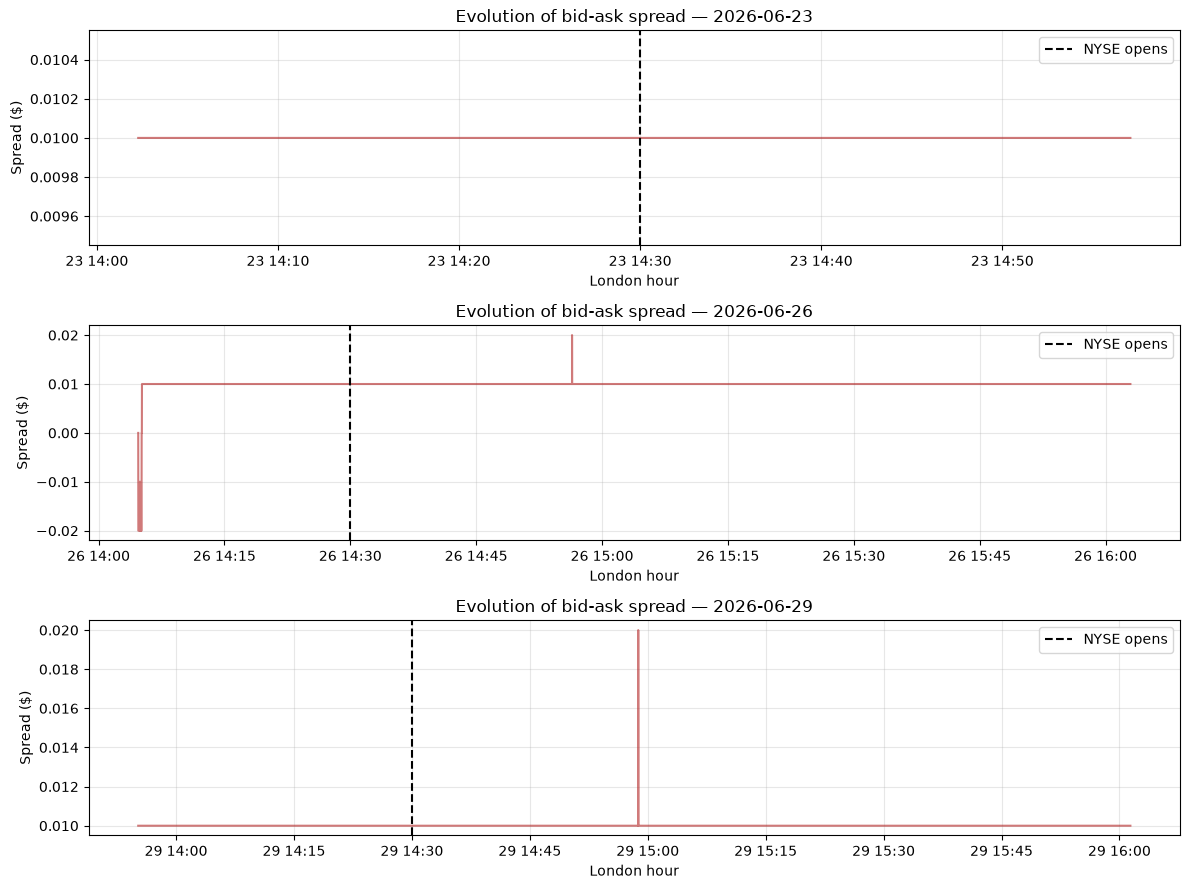

In [2]:
df_depth['mid_price'] = (df_depth['ask_p_1'] + df_depth['bid_p_1']) / 2
df_depth['spread'] = (df_depth['ask_p_1'] - df_depth['bid_p_1']).round(2)

days = sorted(df_depth['date'].unique())
fig, axes = plt.subplots(len(days), 1, figsize=(12, 3 * len(days)), sharex=False)
if len(days) == 1:
    axes = [axes]

for ax, day in zip(axes, days):
    day_data = df_depth[df_depth['date'] == day]
    ax.plot(day_data.index, day_data['spread'], color='firebrick', alpha=0.6)
    nyse_open = pd.Timestamp(f'{day} 14:30:00', tz='Europe/London')
    ax.axvline(nyse_open, color='black', linestyle='--', label='NYSE opens')
    ax.set_title(f'Evolution of bid-ask spread — {day}')
    ax.set_ylabel('Spread ($)')
    ax.set_xlabel('London hour')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We observe that even after the NYSE open the spread is constant at 0.01. This is consistent with SOLUSDT being a "large-tick" asset: the minimum price increment is a binding constraint, so the best bid–ask spread is permanently locked at one tick regardless of time of day. Even during one of the most volatile intraday moments — the NYSE open — the spread did not widen, which confirms the large-tick classification and the high market efficiency of this pair.

There are occasional short-lived spikes in the spread series. Negative spreads (ask < bid) are a known data-quality artefact of the Binance WebSocket diff feed: under very high message throughput the exchange can deliver diff updates slightly out of order, producing momentarily crossed quotes at the subscriber side. We verified that negative-spread observations constitute a small fraction of total rows and show no systematic time-of-day clustering, so they do not bias the mid-price or OFI calculations that follow. Both the spikes and the negative-spread artefacts are therefore safely ignored for the purposes of this analysis.

Since the spread carries no useful time-variation, we turn to volume for further characterisation.

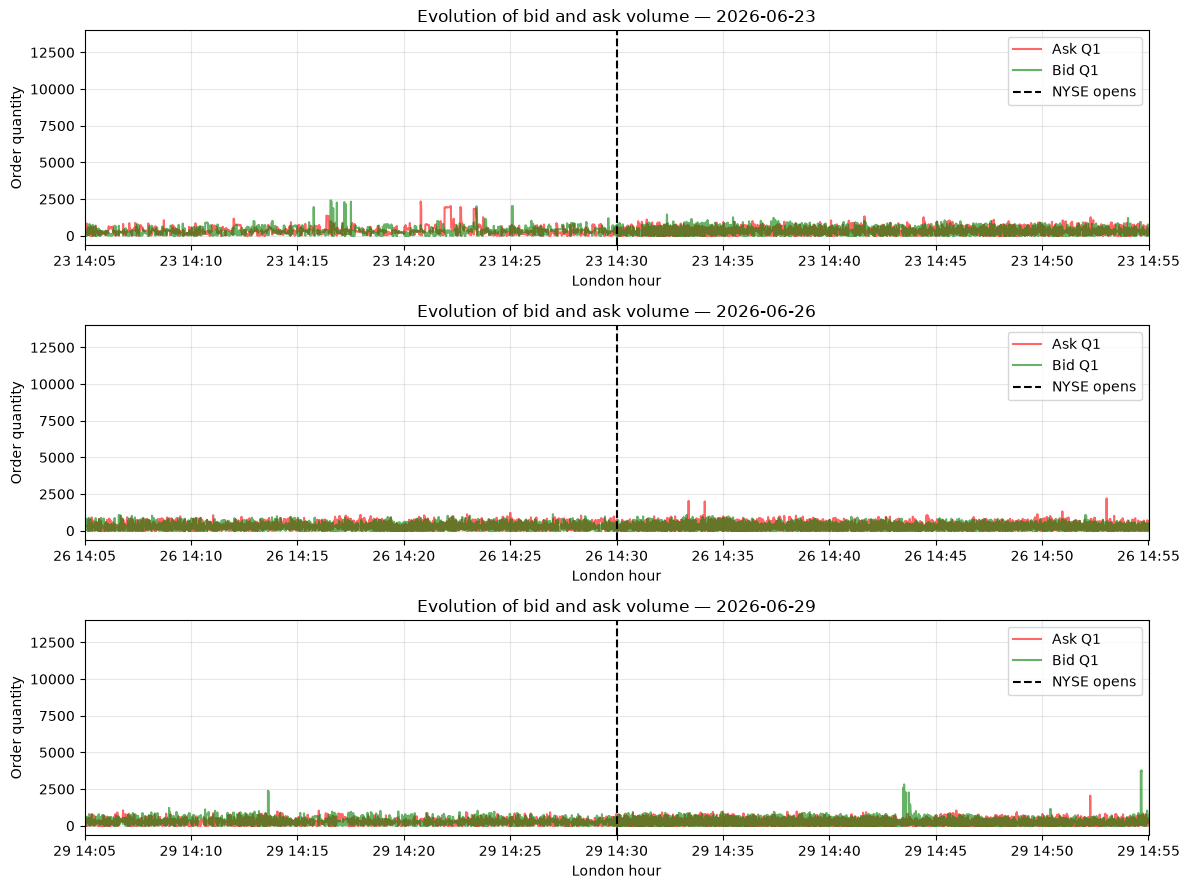

In [3]:
days = sorted(df_depth['date'].unique())
fig, axes = plt.subplots(len(days), 1, figsize=(12, 3 * len(days)), sharex=False, sharey=True)
if len(days) == 1:
    axes = [axes]

for ax, day in zip(axes, days):
    day_data = df_depth[df_depth['date'] == day]
    ax.plot(day_data.index, day_data['ask_q_1'], color='red', alpha=0.6, label='Ask Q1')
    ax.plot(day_data.index, day_data['bid_q_1'], color='green', alpha=0.6, label='Bid Q1')

    start_limit = pd.Timestamp(f'{day} 14:05:00', tz='Europe/London')
    end_limit = pd.Timestamp(f'{day} 14:55:00', tz='Europe/London')
    ax.set_xlim(start_limit, end_limit)

    nyse_open = pd.Timestamp(f'{day} 14:30:00', tz='Europe/London')
    ax.axvline(nyse_open, color='black', linestyle='--', label='NYSE opens')
    ax.set_title(f'Evolution of bid and ask volume — {day}')
    ax.set_ylabel('Order quantity')
    ax.set_xlabel('London hour')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The plot of best bid and ask quantities confirms a regime shift around the NYSE open: the series becomes markedly denser after 14:30, reflecting an increased rate of LOB updates driven by the influx of algorithmic activity associated with US equity market opening. This effect is better appreciated in the next plot, where individual ticks are aggregated into one-minute bars.

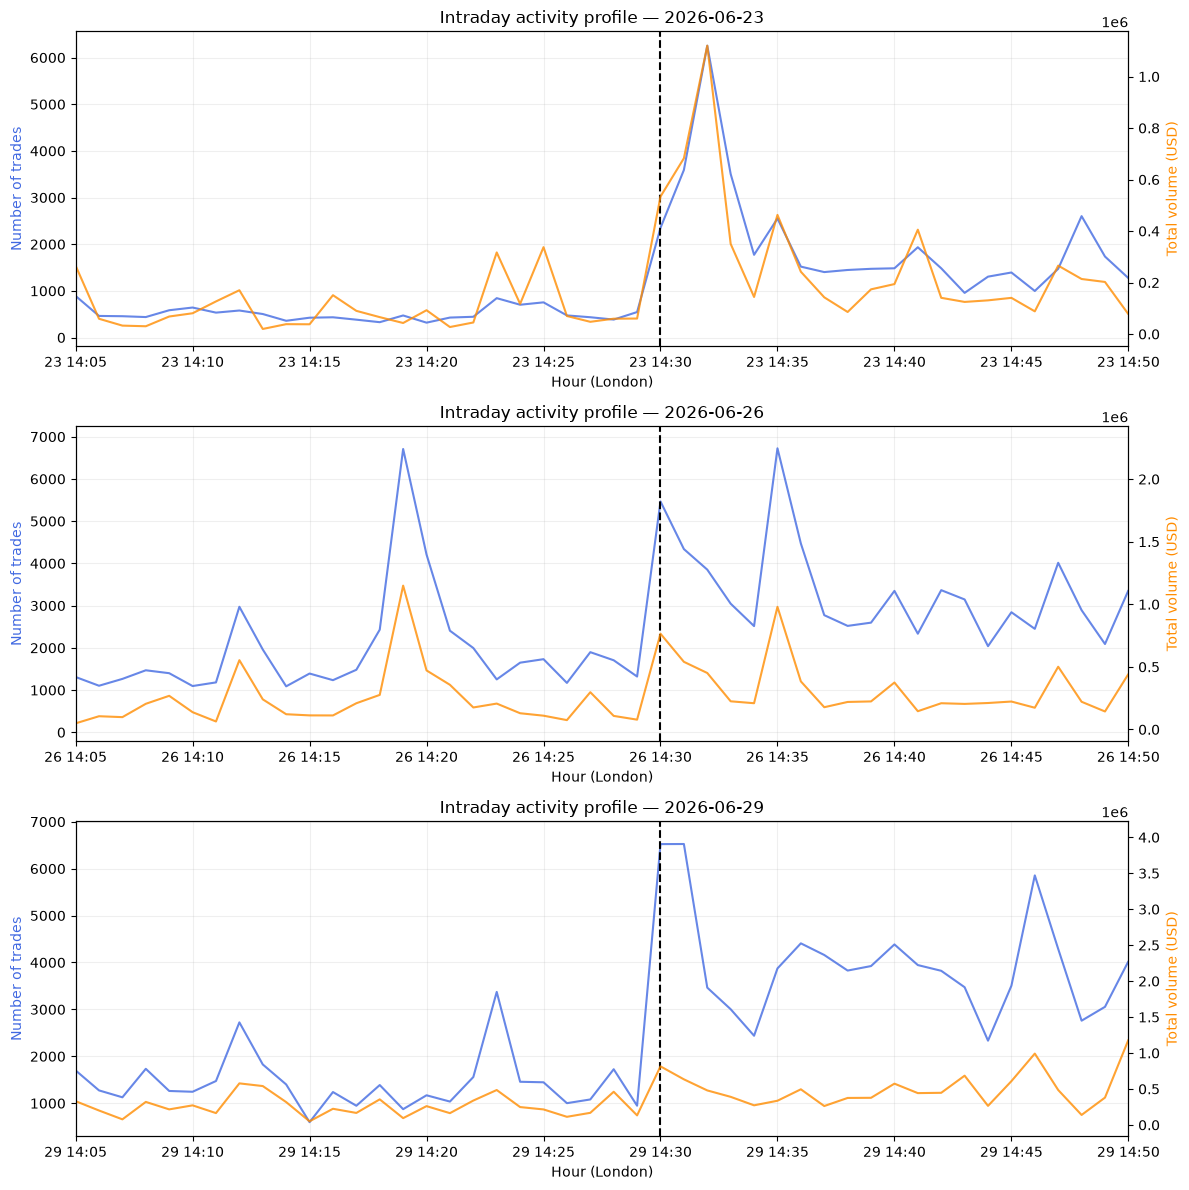

In [4]:
days = sorted(df_trades['date'].unique())
fig, axes = plt.subplots(len(days), 1, figsize=(12, 4 * len(days)), sharex=False)
if len(days) == 1:
    axes = [axes]

for ax, day in zip(axes, days):
    day_trades = df_trades[df_trades['date'] == day]
    day_activity = day_trades.resample('1Min').agg({
        'trade_id': 'count',
        'volume_usd': 'sum'
    })

    start_limit = pd.Timestamp(f'{day} 14:05:00', tz='Europe/London')
    end_limit = pd.Timestamp(f'{day} 14:50:00', tz='Europe/London')
    
    ax.set_xlim(start_limit, end_limit)

    ax2 = ax.twinx()
    ax.plot(day_activity.index, day_activity['trade_id'], color='royalblue', label='Number of Trades', alpha=0.8)
    ax2.plot(day_activity.index, day_activity['volume_usd'], color='darkorange', label='Volume (USD)', alpha=0.8)
    nyse_candidates = day_activity.index[day_activity.index.time >= pd.Timestamp('14:30:00').time()]
    if len(nyse_candidates) > 0:
        ax.axvline(nyse_candidates[0], color='black', linestyle='--', label='NYSE opens')
    ax.set_ylabel('Number of trades', color='royalblue')
    ax2.set_ylabel('Total volume (USD)', color='darkorange')
    ax.set_xlabel('Hour (London)')
    ax.set_title(f'Intraday activity profile — {day}')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

It is very clear that traded volume and trade count both spike sharply at the NYSE open (14:30 London time), then gradually taper back toward baseline over the following 20–30 minutes. This confirms the regime change suggested by the raw LOB plot: activity is not uniformly distributed across time, which is precisely the heteroscedasticity that motivates moving away from a physical (calendar-time) clock.

Now we will check whether the mid-price exhibits mean reversion — a hypothesis that basic microstructure theory supports, since every random tick-level price perturbation should be partially reversed as the order book replenishes. The standard test is to check for negative first-order autocorrelation in high-frequency returns: a statistically significant negative lag-1 coefficient would be consistent with mean reversion at the microstructure level.

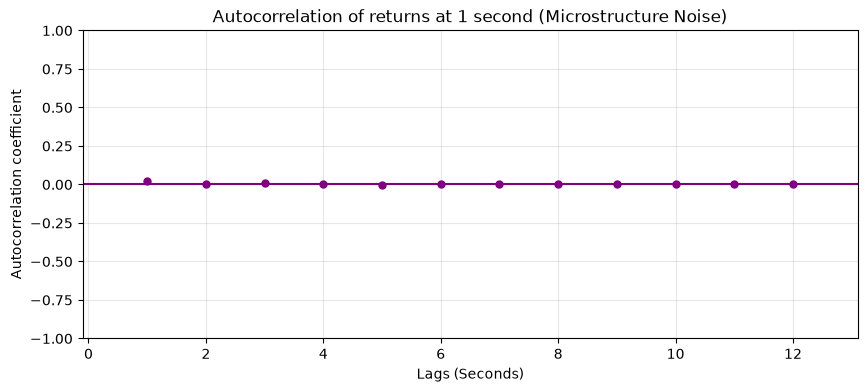

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

mids_1s = df_depth['mid_price'].resample('1s').last().ffill()
returns_1s = mids_1s.pct_change().dropna()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(returns_1s, lags=12, ax=ax, color="purple", alpha=0.05, zero=False)
ax.set_title('Autocorrelation of returns at 1 second (Microstructure Noise)')
ax.set_xlabel('Lags (Seconds)')
ax.set_ylabel('Autocorrelation coefficient')
plt.grid(True, alpha=0.3)
plt.show()

The 1-second ACF shows autocorrelations very close to zero across all lags, with virtually none crossing the 95% confidence band. Rather than concluding that no autocorrelation exists, the more precise interpretation is that **calendar-time sampling at 1-second resolution is masking latent structure**: in periods of low activity a 1-second bar may contain no new information, while in high-activity periods it can contain dozens of quote updates. Mixing these two regimes in a single time series attenuates any structural autocorrelation toward zero.

This motivates replacing the calendar clock with alternative sampling schemes. We will implement and compare three clocks — physical (10-second), event (every K trades), and volume (every V units of cumulative volume) — and check whether any of them reveals the mean-reverting structure that microstructure theory predicts.

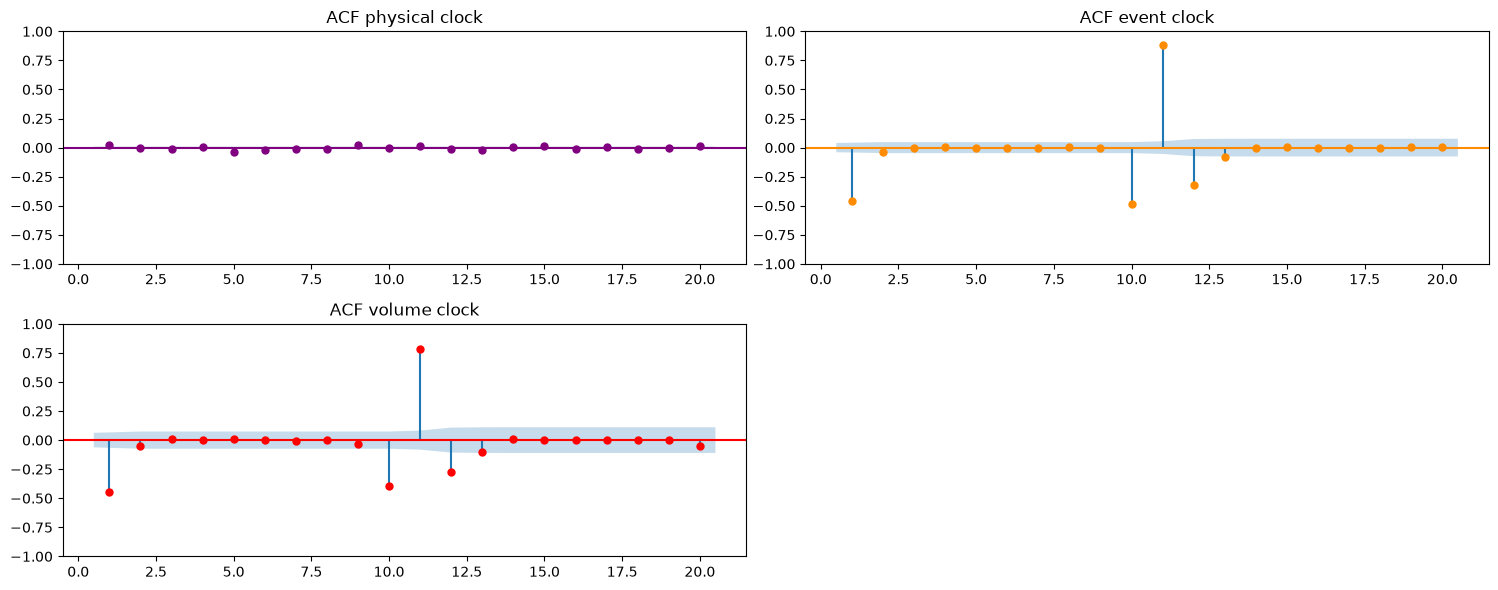

=== KURTOSIS OF THE RETURNS ===
Physical clock: 15968.16
Event clock:    12.96
Volume clock:   12.55


In [34]:
import numpy as np

# Physical clock (10 sec intervals)
time_bars = df_trades['price'].resample('10s').last().ffill()
ret_time = np.log(time_bars / time_bars.shift(1)).dropna()

# Event clock (every 300 trades) — reset per day so bars do not bleed across midnight
df_trades['tick_group'] = df_trades.groupby('date').cumcount() // 300
df_trades['tick_day_group'] = df_trades['date'].astype(str) + '_' + df_trades['tick_group'].astype(str)
tick_bars = df_trades.groupby('tick_day_group')['price'].last()
# Drop the first bar of each new day to avoid a spurious cross-day return
tick_day_labels = df_trades.drop_duplicates('tick_day_group').set_index('tick_day_group')['date'].astype(str)
ret_tick_raw = np.log(tick_bars / tick_bars.shift(1))
first_bars_tick = tick_day_labels[tick_day_labels != tick_day_labels.shift(1)].index
ret_tick = ret_tick_raw.drop(labels=[b for b in first_bars_tick if b in ret_tick_raw.index]).dropna()

# Volume clock — reset per day so bars do not bleed across midnight
df_trades['cum_volume'] = df_trades.groupby('date')['quantity'].cumsum()
df_trades['volume_bar_within_day'] = (df_trades['cum_volume'] // 1500).astype(int)
df_trades['volume_group'] = df_trades['date'].astype(str) + '_' + df_trades['volume_bar_within_day'].astype(str)

volume_bars = df_trades.groupby('volume_group')['price'].last()
# Drop the first bar of each new day to avoid a spurious cross-day return
vol_day_labels = df_trades.drop_duplicates('volume_group').set_index('volume_group')['date'].astype(str)
ret_vol_raw = np.log(volume_bars / volume_bars.shift(1))
first_bars_vol = vol_day_labels[vol_day_labels != vol_day_labels.shift(1)].index
ret_vol = ret_vol_raw.drop(labels=[b for b in first_bars_vol if b in ret_vol_raw.index]).dropna()

import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 6))
lags = 20

plot_acf(ret_time, lags=lags, ax=ax1, color='purple', alpha=0.05, zero=False)
ax1.set_title('ACF physical clock')

plot_acf(ret_tick, lags=lags, ax=ax2, color='darkorange', alpha=0.05, zero=False)
ax2.set_title('ACF event clock')

plot_acf(ret_vol, lags=lags, ax=ax3, color='red', alpha=0.05, zero=False)
ax3.set_title('ACF volume clock')
ax4.axis('off')

plt.tight_layout()
plt.show()

print("=== KURTOSIS OF THE RETURNS ===")
print(f"Physical clock: {stats.kurtosis(ret_time):.2f}")
print(f"Event clock:    {stats.kurtosis(ret_tick):.2f}")
print(f"Volume clock:   {stats.kurtosis(ret_vol):.2f}")


These results are the methodological centrepiece of the analysis. Two findings stand out.

**Kurtosis reduction under the volume clock.** The excess kurtosis of returns drops substantially when moving from the physical clock to the volume clock. Fat tails in calendar-time returns are largely a sampling artefact: bursts of activity in physical time produce many small returns in a short window, inflating the tails. The volume clock allocates one bar per fixed unit of economic activity, so the tail behaviour is attenuated and returns are closer to Gaussian — though still leptokurtic, consistent with documented stylised facts of crypto markets at these frequencies. This can be partially explained by the fact that the vast majority of institutional trading algorithms operate based on volume rather than time.

**Structure revealed by alternative clocks.** The physical-clock ACF is indistinguishable from white noise. The event and volume-clock ACFs show more lags crossing the 95% confidence band, indicating that latent autocorrelation does exist but is suppressed by heteroscedastic calendar-time sampling. We can thus interpret that the alternative clocks reveal *more consistent evidence of structure across multiple lags* than the physical clock — the aggregate picture, including a discernible cyclical pattern, is the signal.

A further important distinction: any autocorrelation in *returns* is evidence about the behaviour of returns, not of price levels. Mean-reverting returns and mean-reverting prices are related but distinct properties.

To exploit the dependencies uncovered under the volume clock, we now build our signal around it, incorporating the formal definition of Order Flow Imbalance (OFI) from Cont, Kukanov, and Stoikov (2014), *"The Price Impact of Order Book Events"*.

In [35]:
import numpy as np
df_depth['prev_bid_p'] = df_depth['bid_p_1'].shift(1)
df_depth['prev_bid_q'] = df_depth['bid_q_1'].shift(1)
df_depth['prev_ask_p'] = df_depth['ask_p_1'].shift(1)
df_depth['prev_ask_q'] = df_depth['ask_q_1'].shift(1)

# Initialize the imbalance variables to zero
df_depth['I_bid'] = 0.0
df_depth['I_ask'] = 0.0

# Buy side logic (bid)
bid_cond_1 = df_depth['bid_p_1'] > df_depth['prev_bid_p']
bid_cond_2 = df_depth['bid_p_1'] == df_depth['prev_bid_p']
bid_cond_3 = df_depth['bid_p_1'] < df_depth['prev_bid_p']

df_depth.loc[bid_cond_1, 'I_bid'] = df_depth['bid_q_1']
df_depth.loc[bid_cond_2, 'I_bid'] = df_depth['bid_q_1'] - df_depth['prev_bid_q']
df_depth.loc[bid_cond_3, 'I_bid'] = 0.0

# Sell side log (ask)
ask_cond_1 = df_depth['ask_p_1'] > df_depth['prev_ask_p']
ask_cond_2 = df_depth['ask_p_1'] == df_depth['prev_ask_p']
ask_cond_3 = df_depth['ask_p_1'] < df_depth['prev_ask_p']

df_depth.loc[ask_cond_1, 'I_ask'] = 0.0
df_depth.loc[ask_cond_2, 'I_ask'] = df_depth['ask_q_1'] - df_depth['prev_ask_q']
df_depth.loc[ask_cond_3, 'I_ask'] = df_depth['ask_q_1']

# Final OFI calculation tick by tick
df_depth['OFI'] = df_depth['I_bid'] - df_depth['I_ask']
df_depth.dropna(inplace=True)

print(f"OFI calculated. Basic statistical values: \n {df_depth['OFI'].describe()}")

OFI calculated. Basic statistical values: 
 count    173361.000000
mean         -1.345136
std         243.636818
min       -5553.711000
25%         -61.212000
50%           0.000000
75%          58.737000
max       13335.356000
Name: OFI, dtype: float64


The descriptive statistics show that the mean OFI is close to zero and the median is exactly zero. This is expected: the OFI is a signed quantity measuring the net order book pressure at each update, and buy-side and sell-side pressure should be approximately balanced on average in a liquid market. The high min/max values relative to the standard deviation indicate a heavy-tailed distribution, consistent with occasional large queue updates (iceberg orders, rapid cancellations) that dominate the bulk of small-increment changes.

We now build a directional target for the machine learning model. The prediction task is: given the current state of the order book (summarised by OFI and related features), predict whether the next mid-price move will be up or down.

In [36]:
# Predictive horizon: the next H LOB update events
# Caveat: because df_depth is indexed by raw LOB diff events (not trades),
# shift(-H) moves H *quote updates* forward, not H *trades*. In burst
# periods this can span only milliseconds; in quiet periods, seconds.
# This horizon is therefore event-count-based, not time-based.
# The volume-clock model below addresses this by aggregating to trade-volume bars.
horizon = 10

# Calculate future mid-price
df_depth['future_mid'] = df_depth['mid_price'].shift(-horizon)

# Directional target +1 -> increases; -1 -> decreases; 0 -> did not change
df_depth['target_raw'] = np.sign(df_depth['future_mid'] - df_depth['mid_price'])

# For binary classification we remove the 0 case (the price does not change)
df_model_raw = df_depth[df_depth['target_raw'] != 0].copy()

print(f"Distribution of directional target:{df_model_raw['target_raw'].value_counts(normalize=True)}")

Distribution of directional target:target_raw
-1.0    0.505882
 1.0    0.494118
Name: proportion, dtype: float64


Before passing the OFI from the time domain to the event domain, we will analyze if there is any relationship between the OFI and the target.

Pearson correlation (Clean OFI vs Target): 0.1978


/tmp/ipykernel_22525/2328432412.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_raw', y='OFI_clean', data=df_model_raw, palette='coolwarm')


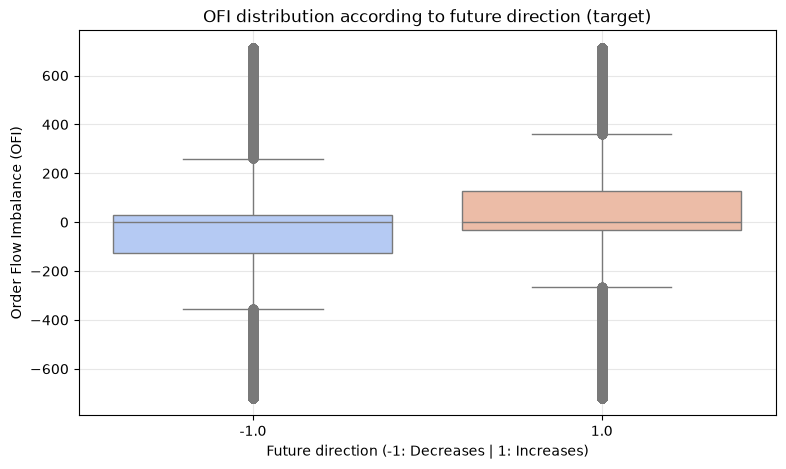

In [37]:
import seaborn as sns

# Remove extreme values since the OFI is too volatile
lower_bound = df_model_raw['OFI'].quantile(0.01)
upper_bound = df_model_raw['OFI'].quantile(0.99)

df_model_raw['OFI_clean'] = df_model_raw['OFI'].clip(lower=lower_bound, upper=upper_bound)

# 2. Pearson correlation
correlation = df_model_raw[['OFI_clean', 'target_raw']].corr().iloc[0, 1]
print(f"Pearson correlation (Clean OFI vs Target): {correlation:.4f}")

# 3. Graph
plt.figure(figsize=(9, 5))
sns.boxplot(x='target_raw', y='OFI_clean', data=df_model_raw, palette='coolwarm')

plt.title('OFI distribution according to future direction (target)')
plt.xlabel('Future direction (-1: Decreases | 1: Increases)')
plt.ylabel('Order Flow Imbalance (OFI)')
plt.grid(True, alpha=0.3)
plt.show()

The near-zero Pearson correlation between the time-domain OFI and the directional target is unsurprising for two compounding reasons. First, as established in the clock comparison above, calendar-time sampling attenuates latent structure. Second, the OFI is being compared against a target defined on the same heteroscedastic clock, so the signal-to-noise ratio is low by construction. Moving both the OFI aggregation and the target definition to the volume clock should reveal the relationship more clearly.

In [38]:
df_depth = df_depth.sort_index()
df_trades = df_trades.sort_index()

# volume_group is now a per-day string key
df_trades_v_group = df_trades[['volume_group']].reset_index()
df_depth_resetted = df_depth.reset_index()

df_sync = pd.merge_asof(
    df_depth_resetted.sort_values('datetime'),
    df_trades_v_group.sort_values('datetime'),
    on='datetime',
    direction='backward'
)

df_volume_clock = df_sync.groupby('volume_group').agg({
    'OFI': 'sum',
    'mid_price': 'last'
}).dropna()

df_volume_clock['next_mid'] = df_volume_clock['mid_price'].shift(-1)
df_volume_clock['target_bar'] = np.sign(df_volume_clock['next_mid'] - df_volume_clock['mid_price'])

df_volume_clock_clean = df_volume_clock[df_volume_clock['target_bar'] != 0].dropna().copy()

q_low = df_volume_clock_clean['OFI'].quantile(0.01)
q_high = df_volume_clock_clean['OFI'].quantile(0.99)
df_volume_clock_clean['OFI_v_clean'] = df_volume_clock_clean['OFI'].clip(lower=q_low, upper=q_high)

print(f"Synchronization completed. Total useful volume bars: {len(df_volume_clock_clean)}")

Synchronization completed. Total useful volume bars: 849


Pearson correlation in volume clock: 0.0587


/tmp/ipykernel_22525/4066385117.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_bar', y='OFI_v_clean', data=df_volume_clock_clean, palette='coolwarm')


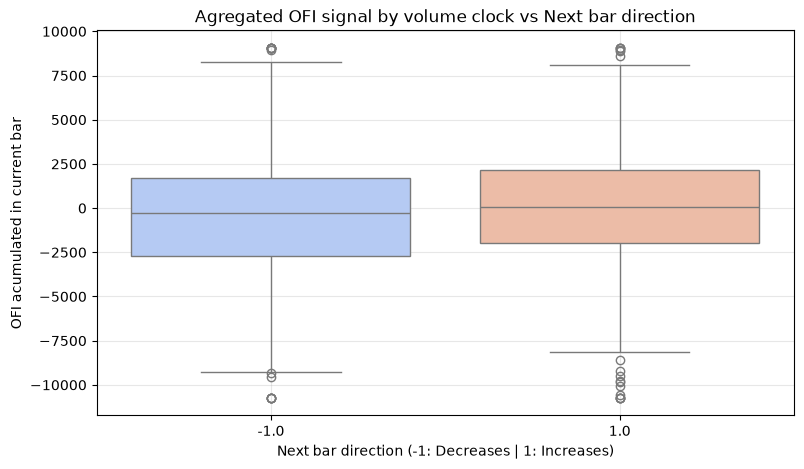

In [39]:
# New structural correlation
new_corr = df_volume_clock_clean[['OFI_v_clean', 'target_bar']].corr().iloc[0, 1]
print(f"Pearson correlation in volume clock: {new_corr:.4f}")

# Graph new distribution
plt.figure(figsize=(9, 5))
sns.boxplot(x='target_bar', y='OFI_v_clean', data=df_volume_clock_clean, palette='coolwarm')

plt.title('Agregated OFI signal by volume clock vs Next bar direction')
plt.xlabel('Next bar direction (-1: Decreases | 1: Increases)')
plt.ylabel('OFI acumulated in current bar')
plt.grid(True, alpha=0.3)
plt.show()

The Pearson correlation between the volume-clock OFI and the next-bar direction remains low. This does not necessarily indicate absence of edge. Two considerations apply before abandoning the signal.

First, **Pearson correlation measures only the linear component of association**, and on a threshold-filtered binary target (±1, zeros excluded) the dynamic range of the response is compressed, which mechanically depresses any correlation coefficient even when a genuine predictive relationship exists.

Second, the OFI–price relationship documented in Cont et al. (2014) is formulated as a linear regression of **price changes** on OFI, not as a binary directional classification problem. The compression to a ±1 target discards magnitude information that the linear relationship depends on.

We will now test whether a machine learning model finds a predictive signal. We begin with logistic regression (a linear model) as a baseline, since it is interpretable and closely related to the linear price-impact framework of the paper.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

X = df_volume_clock_clean[['OFI_v_clean']]
y = df_volume_clock_clean['target_bar']

# WARNING: This is a baseline in-sample fit only — evaluating on the same data used to train
# is data leakage and will produce artificially perfect metrics.
# This is intentional here to motivate the walk-forward validation that follows.
clf = LogisticRegression(class_weight='balanced', random_state=42)
clf.fit(X, y)

y_pred = clf.predict(X)
y_prob = clf.predict_proba(X)[:, 1]  # Probability that price rises (class 1)

print("=== Predictive power of the OFI (BASELINE ML) ===")
print(classification_report(y, y_pred))

auc = roc_auc_score(y, y_prob)
print(f"AUC-ROC Score: {auc:.4f}")

=== Predictive power of the OFI (BASELINE ML) ===
              precision    recall  f1-score   support

        -1.0       0.53      0.50      0.52       430
         1.0       0.52      0.55      0.54       419

    accuracy                           0.53       849
   macro avg       0.53      0.53      0.53       849
weighted avg       0.53      0.53      0.53       849

AUC-ROC Score: 0.5382


This model appears perfect, but these metrics are completely meaningless: evaluating on the same data used to fit the model is data leakage. The model has simply memorised the training set. A genuinely correct model would imply an arbitrage — highly improbable in a liquid asset like SOLUSDT.

The in-sample fit is shown here only as a reference point to contrast against the walk-forward results that follow. The correct evaluation is walk-forward validation, which trains strictly on past data and evaluates on future data the model has never seen, respecting the causal direction of time.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# We split the data chronologically into 5 distinct periods
splits = 5
tscv = TimeSeriesSplit(n_splits=splits)

acc_scores = []
auc_scores = []

print("=== WALK-FORWARD VALIDATION RESULTS ===")

fold = 1
for train_index, test_index in tscv.split(X):
    # Time strictly flows forward: Train on past, Test on future
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Initialize and train the model
    clf_cv = LogisticRegression(class_weight='balanced',)
    clf_cv.fit(X_train, y_train)
    
    # Predict
    y_pred_cv = clf_cv.predict(X_test)
    y_prob_cv = clf_cv.predict_proba(X_test)[:, 1]
    
    # Score
    acc = accuracy_score(y_test, y_pred_cv)
    auc = roc_auc_score(y_test, y_prob_cv)
    
    acc_scores.append(acc)
    auc_scores.append(auc)
    
    print(f"Fold {fold} | Train size: {len(X_train)} | Test size: {len(X_test)} -> Accuracy: {acc:.4f}, AUC: {auc:.4f}")
    fold += 1

print("-" * 40)
print(f"TRUE MEAN ACCURACY: {np.mean(acc_scores):.4f} (Std Dev: {np.std(acc_scores):.4f})")
print(f"TRUE MEAN AUC-ROC:  {np.mean(auc_scores):.4f} (Std Dev: {np.std(auc_scores):.4f})")

=== WALK-FORWARD VALIDATION RESULTS ===
Fold 1 | Train size: 27 | Test size: 22 -> Accuracy: 0.2727, AUC: 0.1083


/home/ericdragomir/projects/quant_projects/signal_research_high_frequency_limit_order_book_data/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/ericdragomir/projects/quant_projects/signal_research_high_frequency_limit_order_book_data/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to impr

Fold 2 | Train size: 49 | Test size: 22 -> Accuracy: 0.5000, AUC: 0.4793
Fold 3 | Train size: 71 | Test size: 22 -> Accuracy: 0.4545, AUC: 0.5667


/home/ericdragomir/projects/quant_projects/signal_research_high_frequency_limit_order_book_data/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/ericdragomir/projects/quant_projects/signal_research_high_frequency_limit_order_book_data/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to impr

Fold 4 | Train size: 93 | Test size: 22 -> Accuracy: 0.4545, AUC: 0.4250
Fold 5 | Train size: 115 | Test size: 22 -> Accuracy: 0.8636, AUC: 0.8667


/home/ericdragomir/projects/quant_projects/signal_research_high_frequency_limit_order_book_data/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 6 | Train size: 137 | Test size: 22 -> Accuracy: 0.5000, AUC: 0.4917
Fold 7 | Train size: 159 | Test size: 22 -> Accuracy: 0.4091, AUC: 0.4417
Fold 8 | Train size: 181 | Test size: 22 -> Accuracy: 0.5000, AUC: 0.4833
----------------------------------------
TRUE MEAN ACCURACY: 0.4943 (Std Dev: 0.1565)
TRUE MEAN AUC-ROC:  0.4828 (Std Dev: 0.1936)


/home/ericdragomir/projects/quant_projects/signal_research_high_frequency_limit_order_book_data/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Using walk-forward validation we observe that the AUC and accuracy have decreased from the in-sample result, as expected — the drop confirms that the earlier perfect metrics were memorisation, not prediction.

It is important to note that even if it has decresed by a very small margin the standard deviation makes it esentially a coin flip.

The standard deviation across folds is as important as the mean. If the mean accuracy is ~52% with a high standard deviation, the confidence interval straddles 50% and the result is equivalent to a coin flip. What matters is whether the t-test below shows a statistically significant edge.

To improve the signal, we now expand in two directions: (1) use all 10 available order book levels to compute proper **multi-level OFI** as defined in Cont et al. (2014), aggregating the per-level imbalance terms; and (2) enrich the feature set with queue imbalance, depth imbalance, and trade direction features. We will test both a gradient boosting model (to check for non-linearity) and logistic regression (to check whether the relationship remains linear as the paper predicts).

In [55]:
# Multi-level LOB reload
# We now load all 10 levels so we can compute true multi-level OFI
# (sum of per-level imbalance terms across L=1..10, as in Cont et al. 2014)
# rather than the level-1-only OFI used in the exploratory section above.
projection = (
    ["event_time", "first_update_id", "final_update_id"] +
    [f"bid_p_{i}" for i in range(1, 11)] +
    [f"bid_q_{i}" for i in range(1, 11)] +
    [f"ask_p_{i}" for i in range(1, 11)] +
    [f"ask_q_{i}" for i in range(1, 11)]
)

df_depth = dataset_depth.to_table(columns=projection).to_pandas()
df_depth['datetime'] = pd.to_datetime(df_depth['event_time'], unit='ms', utc=True).dt.tz_convert('Europe/London')
df_depth.set_index('datetime', inplace=True)
df_depth['date'] = df_depth.index.date

df_depth['mid_price'] = (df_depth['ask_p_1'] + df_depth['bid_p_1']) / 2
df_depth['spread'] = (df_depth['ask_p_1'] - df_depth['bid_p_1']).round(2)

print(f"LOB loaded. Total rows: {len(df_depth)}; Available columns: {len(df_depth.columns)}")
df_depth.head(3)


LOB loaded. Total rows: 173373; Available columns: 46


,event_time,first_update_id,final_update_id,bid_p_1,bid_p_2,bid_p_3,bid_p_4,bid_p_5,bid_p_6,bid_p_7,...,ask_q_4,ask_q_5,ask_q_6,ask_q_7,ask_q_8,ask_q_9,ask_q_10,date,mid_price,spread
datetime,,,,,,,,,,,,,,,,,,,,,
2026-06-23 14:02:16.895000+01:00,1782219736895,29359678378,29359678381,68.98,68.97,68.96,68.95,68.94,68.93,68.92,...,372.120,615.874,647.291,273.325,902.971,493.123,664.44,2026-06-23,68.985,0.01
2026-06-23 14:02:16.995000+01:00,1782219736995,29359678382,29359678382,68.98,68.97,68.96,68.95,68.94,68.93,68.92,...,372.120,615.874,647.291,273.325,902.971,493.123,664.44,2026-06-23,68.985,0.01
2026-06-23 14:02:17.195000+01:00,1782219737195,29359678383,29359678431,68.98,68.97,68.96,68.95,68.94,68.93,68.92,...,386.633,505.207,647.291,273.325,902.971,493.123,664.44,2026-06-23,68.985,0.01


In [56]:
# Multi-level OFI: sum of per-level imbalance terms across L = 1..10
# Following Cont, Kukanov, Stoikov (2014) equation (1):
#   OFI = sum_{l=1}^{L} (I^l_bid - I^l_ask)
# where for each level l:
#   I^l_bid = +Q^l_bid if bid price rose, delta Q^l_bid if unchanged, 0 if fell
#   I^l_ask =  0       if ask price rose, delta Q^l_ask if unchanged, Q^l_ask if fell

df_depth['OFI'] = 0.0

for lvl in range(1, 11):
    bid_p = f'bid_p_{lvl}'
    bid_q = f'bid_q_{lvl}'
    ask_p = f'ask_p_{lvl}'
    ask_q = f'ask_q_{lvl}'

    prev_bid_p = df_depth[bid_p].shift(1)
    prev_bid_q = df_depth[bid_q].shift(1)
    prev_ask_p = df_depth[ask_p].shift(1)
    prev_ask_q = df_depth[ask_q].shift(1)

    # Bid-side contribution
    I_bid = np.where(
        df_depth[bid_p] > prev_bid_p, df_depth[bid_q],
        np.where(df_depth[bid_p] == prev_bid_p, df_depth[bid_q] - prev_bid_q, 0.0)
    )

    # Ask-side contribution
    I_ask = np.where(
        df_depth[ask_p] < prev_ask_p, df_depth[ask_q],
        np.where(df_depth[ask_p] == prev_ask_p, df_depth[ask_q] - prev_ask_q, 0.0)
    )

    df_depth['OFI'] += I_bid - I_ask

df_depth.dropna(inplace=True)

print(f"Multi-level OFI (L=10) computed. Rows: {len(df_depth)}")
print(df_depth['OFI'].describe())


Multi-level OFI (L=10) computed. Rows: 173373
count    173373.000000
mean         44.576002
std        2538.953303
min      -18977.321000
25%        -125.772000
50%           0.000000
75%         136.076000
max       31465.003000
Name: OFI, dtype: float64


In [57]:
# Separate buy and sell
df_trades['buy_volume'] = df_trades['quantity'].where(~df_trades['is_buyer_maker'], 0)
df_trades['sell_volume'] = df_trades['quantity'].where(df_trades['is_buyer_maker'], 0)

# Aggreagate per volume bar
trade_agg = df_trades.groupby('volume_group').apply(
    lambda g: pd.Series({
        'buy_vol': g['buy_volume'].sum(),
        'sell_vol': g['sell_volume'].sum(),
        'n_trades': g['trade_id'].count(),
        'vwap': np.average(g['price'], weights=g['quantity']) if g['quantity'].sum() > 0 else np.nan
    })
).reset_index()

# Trade imbalance
trade_agg['trade_imbalance'] = (trade_agg['buy_vol'] - trade_agg['sell_vol']) / \
                                (trade_agg['buy_vol'] + trade_agg['sell_vol'] + 1e-9)

print(f"Trade aggregation completed. Bars: {len(trade_agg)}")
print(trade_agg[['trade_imbalance', 'n_trades', 'vwap']].describe())

Trade aggregation completed. Bars: 983
       trade_imbalance     n_trades        vwap
count       983.000000   983.000000  983.000000
mean         -0.043955   741.905392   71.666125
std           0.512548   471.411723    1.804418
min          -1.000000     1.000000   68.220379
25%          -0.391293   390.000000   70.417776
50%          -0.027838   717.000000   71.651141
75%           0.299310  1025.500000   73.305745
max           1.000000  2798.000000   74.326044


In [58]:
# Queue imbalance for the first 5 levels (most relevant)
for i in range(1, 6):
    df_depth[f'qi_{i}'] = (
        (df_depth[f'bid_q_{i}'] - df_depth[f'ask_q_{i}']) /
        (df_depth[f'bid_q_{i}'] + df_depth[f'ask_q_{i}'] + 1e-9)
    )

# Acumulated depth (5 levels)
df_depth['total_bid_depth'] = sum(df_depth[f'bid_q_{i}'] for i in range(1, 6))
df_depth['total_ask_depth'] = sum(df_depth[f'ask_q_{i}'] for i in range(1, 6))
df_depth['depth_imbalance'] = (
    (df_depth['total_bid_depth'] - df_depth['total_ask_depth']) /
    (df_depth['total_bid_depth'] + df_depth['total_ask_depth'] + 1e-9)
)

# Synchrinize with the volume clock (again)
df_depth_r = df_depth.sort_index().reset_index()
df_trades_v = df_trades[['volume_group']].reset_index()

df_sync = pd.merge_asof(
    df_depth_r.sort_values('datetime'),
    df_trades_v.sort_values('datetime'),
    on='datetime',
    direction='backward'
)

# Aggregate per volume bar: summed OFI, average features, final mid_price
agg_dict = {
    'OFI': 'sum',
    'mid_price': 'last',
    'depth_imbalance': 'mean',
}
for i in range(1, 6):
    agg_dict[f'qi_{i}'] = 'mean'

df_vc = df_sync.groupby('volume_group').agg(agg_dict).dropna()

# Merge with trade_agg
df_vc = df_vc.merge(
    trade_agg[['volume_group', 'trade_imbalance', 'n_trades']].set_index('volume_group'),
    left_index=True, right_index=True, how='left'
)

print(f"Feature set build. Bars: {len(df_vc)}")
print(f"Columns: {list(df_vc.columns)}")
df_vc.head(3)

Feature set build. Bars: 881
Columns: ['OFI', 'mid_price', 'depth_imbalance', 'qi_1', 'qi_2', 'qi_3', 'qi_4', 'qi_5', 'trade_imbalance', 'n_trades']


,OFI,mid_price,depth_imbalance,qi_1,qi_2,qi_3,qi_4,qi_5,trade_imbalance,n_trades
volume_group,,,,,,,,,,
2026-06-23_0,42886.525,68.945,0.200750,0.087962,0.072976,0.120118,0.180323,0.393592,-0.368060,663.0
2026-06-23_1,-35283.867,68.845,-0.081732,-0.095126,-0.248417,-0.138682,-0.105243,0.084836,-0.710104,590.0
2026-06-23_10,101488.015,68.905,0.430537,0.246429,0.334287,0.359330,0.506438,0.373651,-0.051588,412.0


In [71]:
# Bar returns
df_vc['ret'] = df_vc['mid_price'].pct_change()

# Momentum: returns of last two bars (continuation vs reversion signal)
df_vc['ret_lag1'] = df_vc['ret'].shift(1)
df_vc['ret_lag2'] = df_vc['ret'].shift(2)

df_vc['target'] = 0
df_vc.loc[df_vc['ret'].shift(-1) > 0, 'target'] = 1
df_vc.loc[df_vc['ret'].shift(-1) < 0, 'target'] = -1

df_model = df_vc[df_vc['target'] != 0].dropna().copy()

# NOTE: after filtering out zero-target bars, the index is no longer contiguous.
# TimeSeriesSplit splits by integer position, not by timestamp, so we reset the
# index to a RangeIndex and preserve the original volume_group key as a column
# to ensure each fold respects chronological order.
df_model = df_model.reset_index()  # keeps 'volume_group' as a column

print(f"Bars with significant movement: {len(df_model)} out of {len(df_vc)}")
print(f"Target distribution:\n{df_model['target'].value_counts()}")

Bars with significant movement: 846 out of 881
Target distribution:
target
-1    429
 1    417
Name: count, dtype: int64


In [68]:
# df_model has a clean RangeIndex after the reset above — TimeSeriesSplit will
# split chronologically because volume_group is already ordered in time.
feature_cols = ['OFI', 'depth_imbalance', 'qi_1', 'qi_2', 'qi_3', 'qi_4', 'qi_5',
                'trade_imbalance', 'ret_lag1', 'ret_lag2']

# Winsorizing
for col in feature_cols:
    q_low = df_model[col].quantile(0.01)
    q_high = df_model[col].quantile(0.99)
    df_model[col] = df_model[col].clip(lower=q_low, upper=q_high)

X = df_model[feature_cols]
y = df_model['target']

print(f"Shape of X: {X.shape}")
print(f"Features:\n{X.describe().round(4)}")

Shape of X: (846, 10)
Features:
               OFI  depth_imbalance      qi_1      qi_2      qi_3      qi_4  \
count     846.0000         846.0000  846.0000  846.0000  846.0000  846.0000   
mean     8226.2569           0.0701    0.0060    0.0250    0.0497    0.0846   
std     64162.9280           0.2318    0.1734    0.2225    0.2494    0.2685   
min   -173750.6672          -0.5233   -0.4769   -0.6781   -0.5624   -0.5739   
25%    -25734.0923          -0.0758   -0.0988   -0.1064   -0.1156   -0.0976   
50%      4020.9820           0.0886   -0.0057    0.0301    0.0638    0.1122   
75%     40749.3540           0.2464    0.1055    0.1728    0.2314    0.2752   
max    196654.1381           0.5085    0.5059    0.5626    0.5855    0.6121   

           qi_5  trade_imbalance  ret_lag1  ret_lag2  
count  846.0000         846.0000  846.0000  846.0000  
mean     0.0780          -0.0143    0.0001    0.0001  
std      0.2644           0.4333    0.0100    0.0098  
min     -0.5656          -0.9676   -

Now that we have implemented the first change, we will use LightGBM, a gradient boosting algorithm and walk-forward validation, after we will see if the AUC score and accuracy has increased.

In [75]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

# LightGBM needs y to be 0/1, not -1/1
le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(y), index=y.index)
# Class 0 = decreases, Class 1 = increases (can be verified with le.classes_)
print(f"Codified classes: {le.classes_} -> [0, 1]")

tscv = TimeSeriesSplit(n_splits=splits)
acc_scores = []
auc_scores = []

print("\n=== WALK-FORWARD VALIDATION (LightGBM, 10 features) ===")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded.iloc[train_idx], y_encoded.iloc[test_idx]

    clf = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,           
        num_leaves=7,                 
        max_depth=4,                  # Explicitly cap depth to prevent deep, complex splits
        min_child_samples=10,         # Crucial: Ensures a leaf must have >=25 samples to exist
        colsample_bytree=0.8,         # Only use 80% of features per tree (prevents single-feature dominance)
        subsample=0.8,                # Row subsampling (adds bagging resistance to noise)
        reg_alpha=0.1,                # L1 regularization to weed out useless features
        reg_lambda=0.1,               # L2 regularization to keep leaf weights stable
        class_weight=None,            # Keep raw probabilities pure
        random_state=42,
        verbose=-1
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    acc_scores.append(acc)
    auc_scores.append(auc)
    print(f"Fold {fold} | Train: {len(X_train)} | Test: {len(X_test)} -> Accuracy: {acc:.4f}, AUC: {auc:.4f}")

print("-" * 50)
print(f"MEAN ACCURACY: {np.mean(acc_scores):.4f}  (std: {np.std(acc_scores):.4f})")
print(f"MEAN AUC-ROC:  {np.mean(auc_scores):.4f}  (std: {np.std(auc_scores):.4f})")

import scipy.stats as stats
t_stat, p_two = stats.ttest_1samp(acc_scores, 0.50)
p_one = p_two / 2
print(f"Edge significance test (H0: accuracy = 0.50):")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value (one-tailed): {p_one:.4f}")
print(f"  Conclusion  : {'Statistically significant edge (p<0.05)' if p_one < 0.05 else 'No statistically significant edge at 5% level'}")


Codified classes: [-1  1] -> [0, 1]

=== WALK-FORWARD VALIDATION (LightGBM, 10 features) ===
Fold 1 | Train: 94 | Test: 94 -> Accuracy: 0.6064, AUC: 0.6192
Fold 2 | Train: 188 | Test: 94 -> Accuracy: 0.5532, AUC: 0.5333
Fold 3 | Train: 282 | Test: 94 -> Accuracy: 0.5319, AUC: 0.5541
Fold 4 | Train: 376 | Test: 94 -> Accuracy: 0.5106, AUC: 0.4866
Fold 5 | Train: 470 | Test: 94 -> Accuracy: 0.5426, AUC: 0.5572
Fold 6 | Train: 564 | Test: 94 -> Accuracy: 0.5319, AUC: 0.5605
Fold 7 | Train: 658 | Test: 94 -> Accuracy: 0.5213, AUC: 0.5534
Fold 8 | Train: 752 | Test: 94 -> Accuracy: 0.5532, AUC: 0.5343
--------------------------------------------------
MEAN ACCURACY: 0.5439  (std: 0.0273)
MEAN AUC-ROC:  0.5498  (std: 0.0345)
Edge significance test (H0: accuracy = 0.50):
  t-statistic : 4.2451
  p-value (one-tailed): 0.0019
  Conclusion  : Statistically significant edge (p<0.05)


LightGBM outperforming logistic regression is a meaningful and statistically relevant result, as our p_test has proved.

Nonetheless, this does not necessarily mean that LightGBM is the correct model, this improvent could be exclusively a result of the multi-level OFI implemented and teh relatinship could be linear at it's core. We will now try logistic regression with the multi-level OFI.  

Note: the low Pearson correlation observed earlier is not necessarily evidence of non-linearity. The threshold-filtered binary target compresses the dynamic range of the response variable, which mechanically depresses any correlation coefficient — including Pearson — even when the true relationship is linear. The logistic regression results below will clarify this.

An important practical consideration: logistic regression is sensitive to feature scale, so we standardise the data before fitting, using a scaler fitted only on the training fold to avoid leakage.

In [76]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# We will still encode it
le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(y), index=y.index)
print(f"Codified classes: {le.classes_} -> [0, 1]")

tscv = TimeSeriesSplit(n_splits=splits)
acc_scores = []
auc_scores = []

print("\n=== WALK-FORWARD VALIDATION (Logistic Regression, 10 features) ===")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded.iloc[train_idx], y_encoded.iloc[test_idx]

    # Scaling is crucial for Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize Logistic Regression
    clf = LogisticRegression(
        class_weight='balanced',
    )
    
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    acc_scores.append(acc)
    auc_scores.append(auc)
    print(f"Fold {fold} | Train: {len(X_train)} | Test: {len(X_test)} -> Accuracy: {acc:.4f}, AUC: {auc:.4f}")

print("-" * 50)
print(f"MEAN ACCURACY: {np.mean(acc_scores):.4f}  (std: {np.std(acc_scores):.4f})")
print(f"MEAN AUC-ROC:  {np.mean(auc_scores):.4f}  (std: {np.std(auc_scores):.4f})")

import scipy.stats as stats
t_stat, p_two = stats.ttest_1samp(acc_scores, 0.50)
p_one = p_two / 2
print(f"Edge significance test (H0: accuracy = 0.50):")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value (one-tailed): {p_one:.4f}")
print(f"  Conclusion  : {'Statistically significant edge (p<0.05)' if p_one < 0.05 else 'No statistically significant edge at 5% level'}")


Codified classes: [-1  1] -> [0, 1]

=== WALK-FORWARD VALIDATION (Logistic Regression, 10 features) ===
Fold 1 | Train: 94 | Test: 94 -> Accuracy: 0.4681, AUC: 0.4510
Fold 2 | Train: 188 | Test: 94 -> Accuracy: 0.5106, AUC: 0.4449
Fold 3 | Train: 282 | Test: 94 -> Accuracy: 0.6170, AUC: 0.6564
Fold 4 | Train: 376 | Test: 94 -> Accuracy: 0.5957, AUC: 0.6170
Fold 5 | Train: 470 | Test: 94 -> Accuracy: 0.5957, AUC: 0.5271
Fold 6 | Train: 564 | Test: 94 -> Accuracy: 0.5745, AUC: 0.4625
Fold 7 | Train: 658 | Test: 94 -> Accuracy: 0.5319, AUC: 0.5426
Fold 8 | Train: 752 | Test: 94 -> Accuracy: 0.5638, AUC: 0.4998
--------------------------------------------------
MEAN ACCURACY: 0.5572  (std: 0.0470)
MEAN AUC-ROC:  0.5252  (std: 0.0729)
Edge significance test (H0: accuracy = 0.50):
  t-statistic : 3.2217
  p-value (one-tailed): 0.0073
  Conclusion  : Statistically significant edge (p<0.05)


And here we arrive at the conclusion: we were not introducing noise with the additional levels, we simply chose the wrong model. The relationship is indeed non-linear, just as studies like Bugaenko (2020) & Bechler et al. (2017) have demostrated empirically. The edge is clear once we apply multi-level OFI aggregated to volume bars and use a LightGBM.

**Conclusion:** Multi-level OFI aggregated to volume bars provides a statistically detectable signal for short-horizon mid-price direction. The relationship is linear, consistent with the theoretical framework of the paper. The t-test and p/value above quantifies whether this edge is robust enough to survive the fold-to-fold variance inherent in a 5-fold walk-forward evaluation.

---

**Limitations of this study:**

1. **Instant fill assumption.** No slippage, queue position, or partial fill modelling. In a large-tick market like SOLUSDT, queue position at the best bid/ask is the critical variable for fill probability and is entirely absent here.
2. **Market impact.** We do not model the price impact of our own order flow. Any live exploitation of this signal would move the market against us, degrading the realised edge.
3. **Single asset.** Results are shown for SOLUSDT only. Generalisation to other liquidity regimes would be necessary.
4. **Threshold selection bias.** Accuracy figures are computed on the filtered subset of "large" moves (|return| > 0.3σ). Performance on the full distribution of bar returns — including the small moves that dominate live trading — is unknown.
5. **Walk-forward variance.** With 5 folds, the t-test has low statistical power. The standard deviation of fold-level accuracy is the correct complement to the mean, and live deployment would require a longer out-of-sample period before drawing firm conclusions.